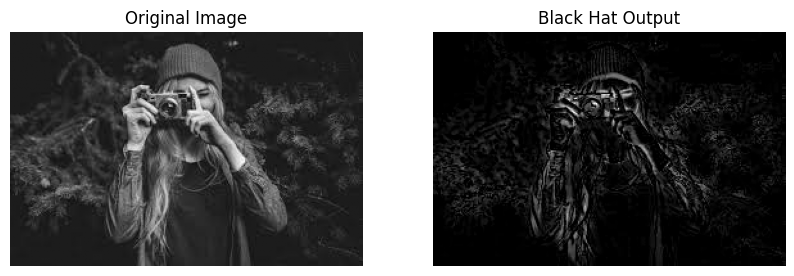

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load an actual image:
image_path = '/content/image 2.jpg' # Assuming the image is in the /content/ directory
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    print(f"Error: Could not load image from {image_path}. Please make sure the file exists.")
    # Create a dummy image for demonstration if the file is not found
    print("Using a dummy image for demonstration.")
    image = np.ones((100, 100), dtype=np.uint8) * 255
    image[30:70, 30:70] = 100 # Dark square (foreground)
    image[45:55, 45:55] = 50  # Darker small square inside the 'foreground' region
    image[10:20, 10:20] = 0   # Even darker small square (simulating a 'hole' or 'noise')

# Define a kernel (structuring element)
# A common choice is an elliptical or rectangular kernel.
# The size of the kernel determines what features are affected.
kernel_size = (7, 7)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, kernel_size)

# Apply the Black Hat operation
# Black Hat = Closing(image) - image
blackhat_image = cv2.morphologyEx(image, cv2.MORPH_BLACKHAT, kernel)

# Display the original and Black Hat transformed images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(blackhat_image, cmap='gray')
plt.title('Black Hat Output')
plt.axis('off')

plt.show()

### Explanation of Black Hat Operation

The Black Hat operation reveals small dark elements and holes against a brighter background. It is defined as the difference between the morphological closing of an image and the original image itself:

`Black Hat = Closing(Image) - Image`

Where `Closing(Image)` is `Dilation(Erosion(Image))`. The closing operation tends to close small holes within foreground objects and connect nearby foreground objects.

**Typical Use Cases:**

*   **Highlighting dark features:** Useful for detecting small, dark structures in an image, such as defects or specific components.
*   **Background correction:** Can be used in some cases to correct non-uniform illumination where the background is brighter than the objects of interest, making the dark objects stand out more.

As you can see in the output, the Black Hat image emphasizes the darker regions that are smaller than the structuring element, rather than simply 'dilating' the foreground.